In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, matplotlib.ticker as ticker, sys, os, csv, shutil, time
from scipy.optimize import least_squares
from itertools import chain
from si_units import BAR, KELVIN
from pathlib import Path
from feos.eos import EquationOfState, PhaseDiagram
from feos.pcsaft import PcSaftParameters
from feos.eos.estimator import Estimator, Loss, DataSet, Phase

sys.path.append("..")
import PLOT_SETTINGS as ps

plot_dir = Path("PLOTS")
if plot_dir.exists():
    shutil.rmtree(plot_dir)
plot_dir.mkdir()

mixture = "CO2-Ar"

notebook_start = time.perf_counter()

In [2]:
def eos_from_kij(kij):
    """Returns equation of state (PC-SAFT) for current kij."""
    global parameters
    p = PcSaftParameters.new_binary(parameters.pure_records, kij)
    return EquationOfState.pcsaft(p)

def cost(kij, estimator):
    """Calculates cost function for current parameters."""
    return estimator.cost(eos_from_kij(kij))

In [3]:

def VLE_PLOT(data, cols, temperature, kij):

    isotherm    = data[data[cols["T"]] == temperature]
    
    if isotherm.empty:
        raise ValueError(f"No data available for T = {temperature} K")

    fig, ax = ps.plot_init()
    i = 0

    # Experimental data
    ax.plot(1-isotherm[cols["x1"]], isotherm[cols["P"]],
        color='blue', marker=ps.markers[i % len(ps.markers)],
        linestyle="", markersize=ps.markersize, markeredgewidth=ps.markeredgewidth,
        label=isotherm.source.iloc[0] + f" (T = {temperature} K)")

    ax.plot(1-isotherm[cols["y1"]], isotherm[cols["P"]],
        color='red', marker=ps.markers[i % len(ps.markers)],
        linestyle="", markersize=ps.markersize, markeredgewidth=ps.markeredgewidth,)

    # PC-SAFT predictions
    vle = PhaseDiagram.binary_vle(eos_from_kij(kij),temperature * KELVIN, npoints=100)

    ax.plot(vle.vapor.molefracs[:, 1], vle.vapor.pressure / BAR,
        color='red', linewidth=ps.linewidth, linestyle="-",
        label=fr"PC-SAFT ($k_{{ij}} = {kij:.3f}$)")

    ax.plot(vle.liquid.molefracs[:, 1], vle.liquid.pressure / BAR,
        color='blue', linewidth=ps.linewidth, linestyle="-")

    ax.minorticks_on()
    ymax = (vle.liquid.pressure / BAR).max()
    
    ax.xaxis.set_major_locator(ticker.MultipleLocator(0.1))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.05))
    
    if ymax > 160:
        ax.yaxis.set_major_locator(ticker.MultipleLocator(40))
        ax.yaxis.set_minor_locator(ticker.MultipleLocator(20))
    else:
        ax.yaxis.set_major_locator(ticker.MultipleLocator(20))
        ax.yaxis.set_minor_locator(ticker.MultipleLocator(10))

    ax.set_xlabel(r"$x_{\mathrm{CO_2}}$, $y_{\mathrm{CO_2}}$", fontsize=ps.label_fontsize)
    ax.set_ylabel(r"$P$ / [bar]", fontsize=ps.label_fontsize)
    ax.set_xlim(min(vle.vapor.molefracs[:, 1].min(), vle.liquid.molefracs[:, 1].min())- 0.1, 1.1)
    ax.set_ylim( (vle.liquid.pressure / BAR).min()/1.3, (vle.liquid.pressure / BAR).max() * 1.3)

    ps.style_legend(ax,loc='upper right',ncol=1,borderaxespad=1.0,frame=False)

    legend = ax.get_legend()
    for handle in legend.legend_handles:
        handle.set_color("black")
        handle.set_markerfacecolor("black")
        handle.set_markeredgecolor("black")
        
    ps.save_plot(fig, f"vle_T{int(temperature)}K_kij{kij:.3f}")


In [4]:
parameters  = PcSaftParameters.from_json(["argon", "carbon dioxide"], "parameters_08.json")
pcsaft = EquationOfState.pcsaft(parameters)
parameters

|component|molarweight|$m$|$\sigma$|$\varepsilon$|$\mu$|$Q$|$\kappa_{AB}$|$\varepsilon_{AB}$|$N_A$|$N_B$|$N_C$|
|-|-|-|-|-|-|-|-|-|-|-|-|
|argon|39.962|1|3.37751|117.80903|-|-|-|-|0|0|0|
|carbon dioxide|43.99|2.53096|2.57855|153.31864|-|-|-|-|0|0|0|

In [5]:
data    = pd.read_csv("EXP_DATA_CO2_AR.csv", delimiter=",")
cols = {
    "P": data.columns[0],
    "x1": data.columns[1],
    "y1": data.columns[2],
    "T": data.columns[3]
}

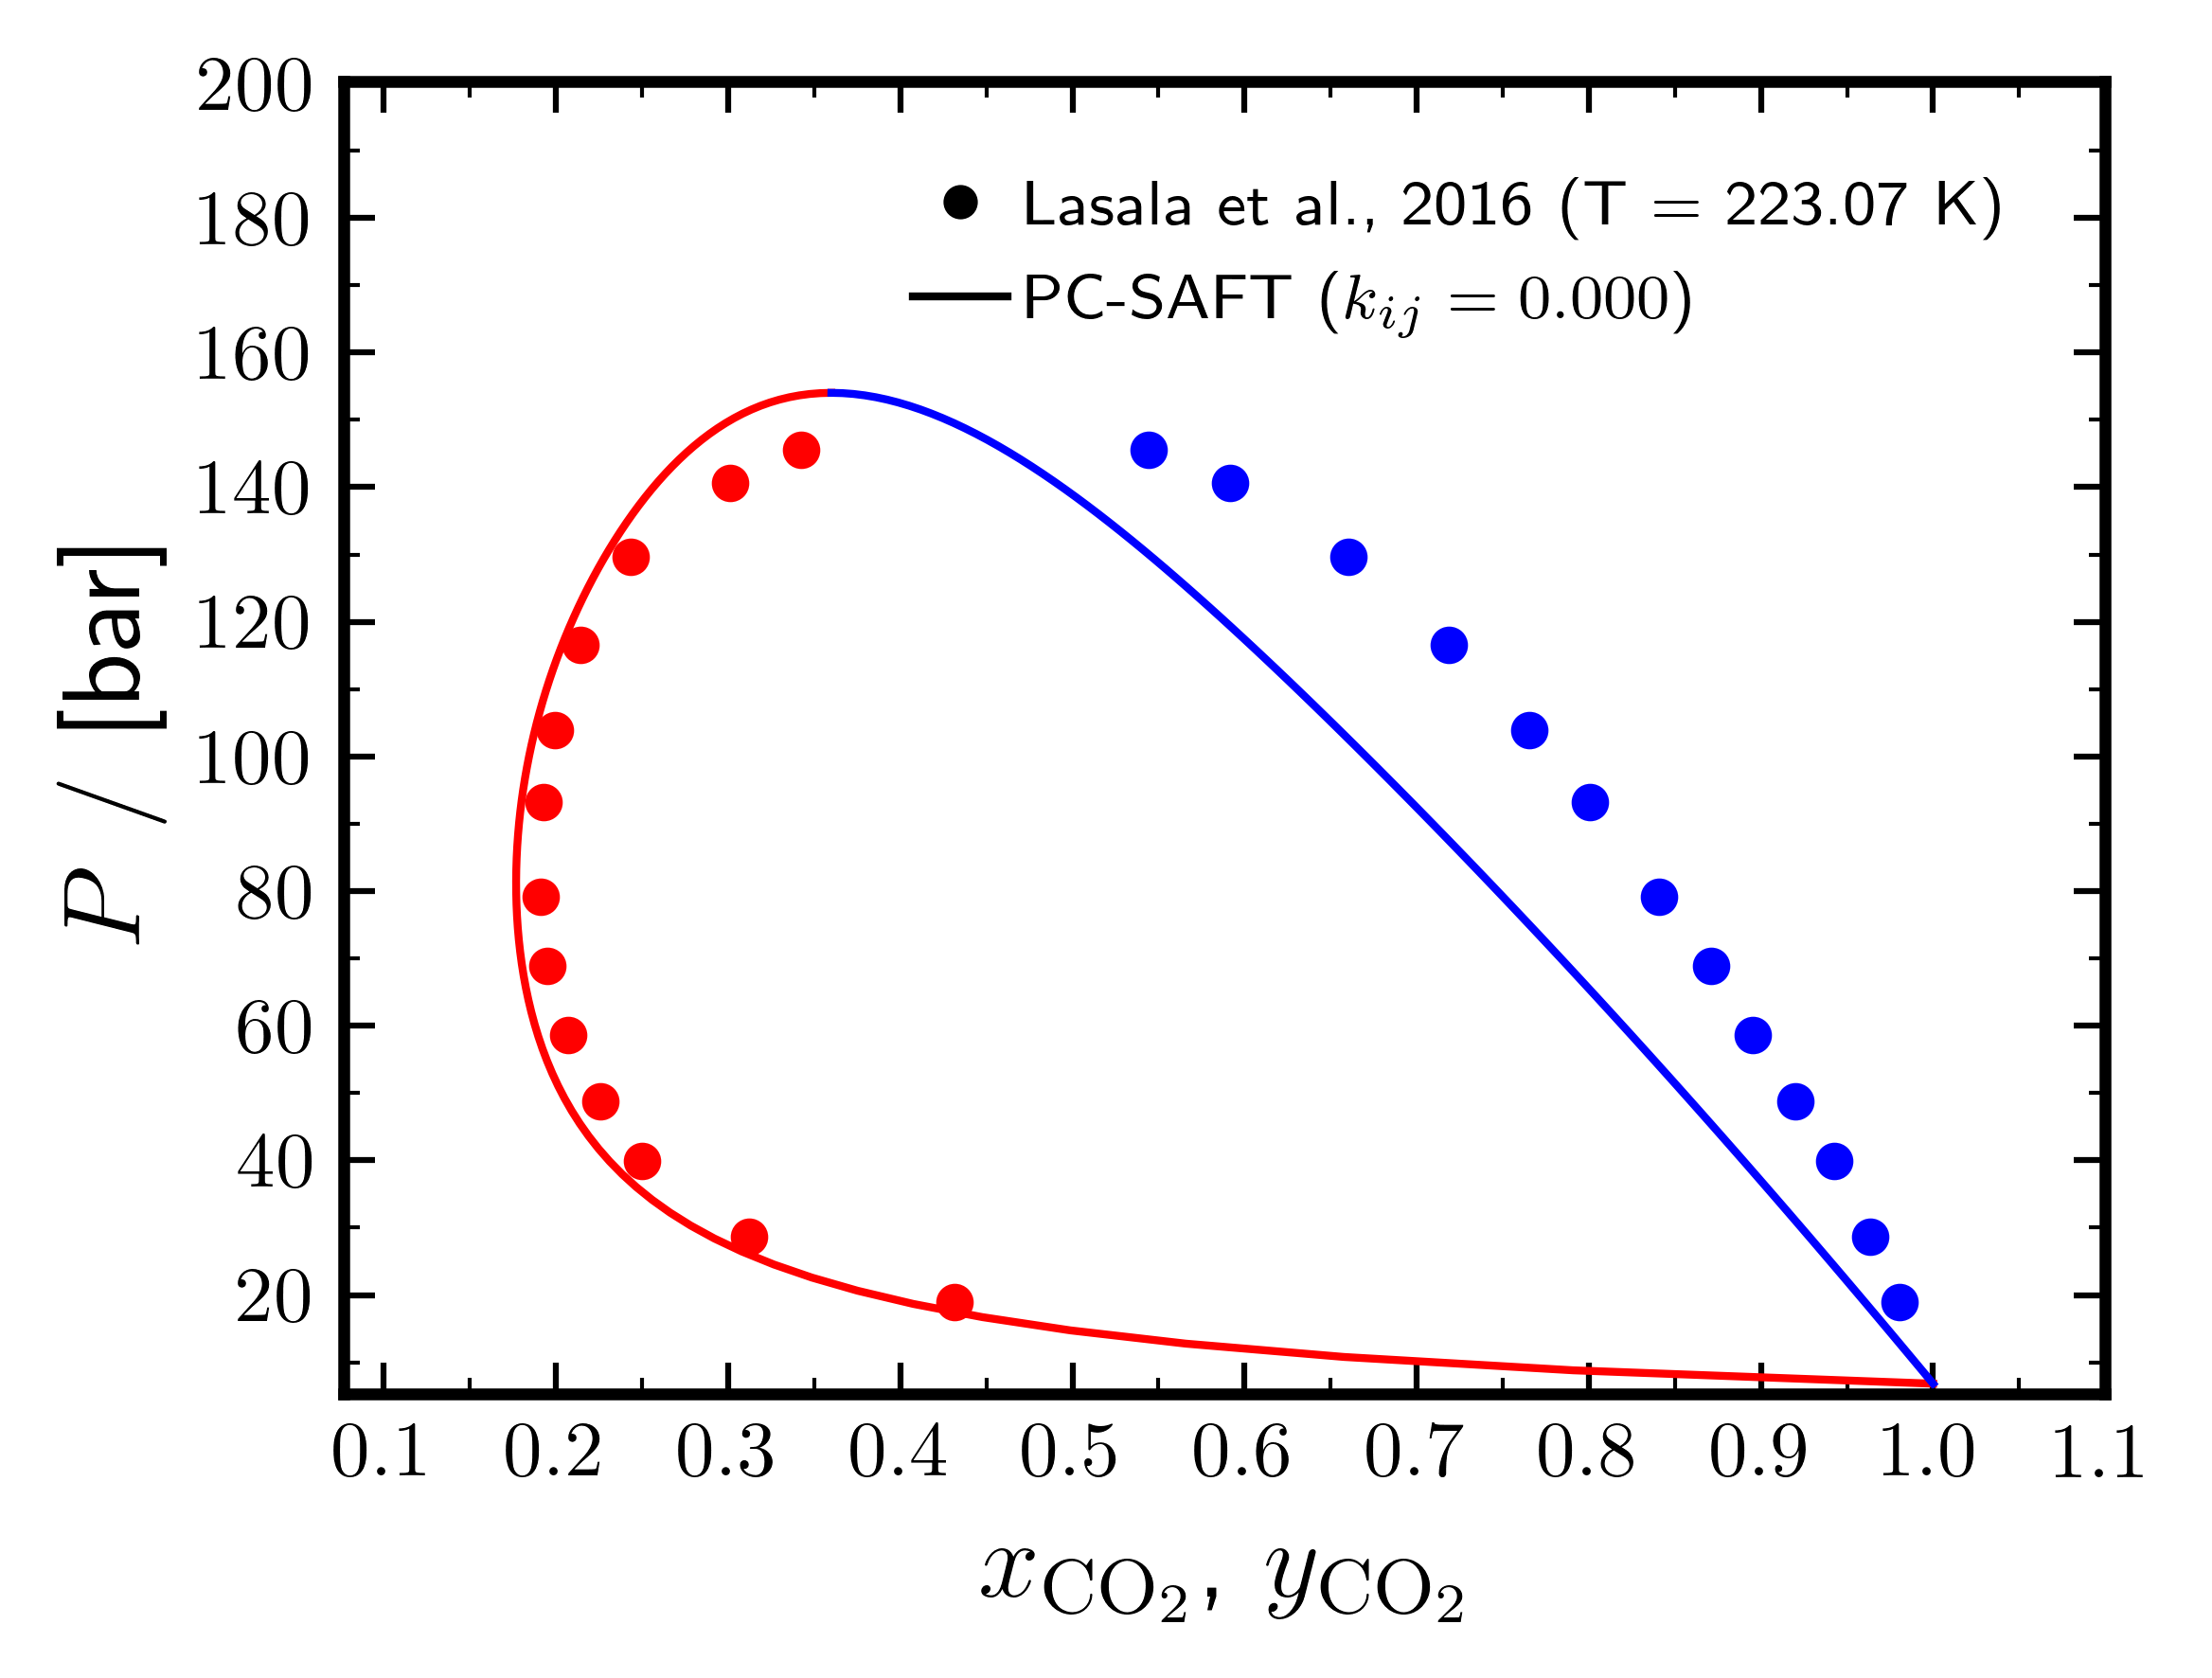

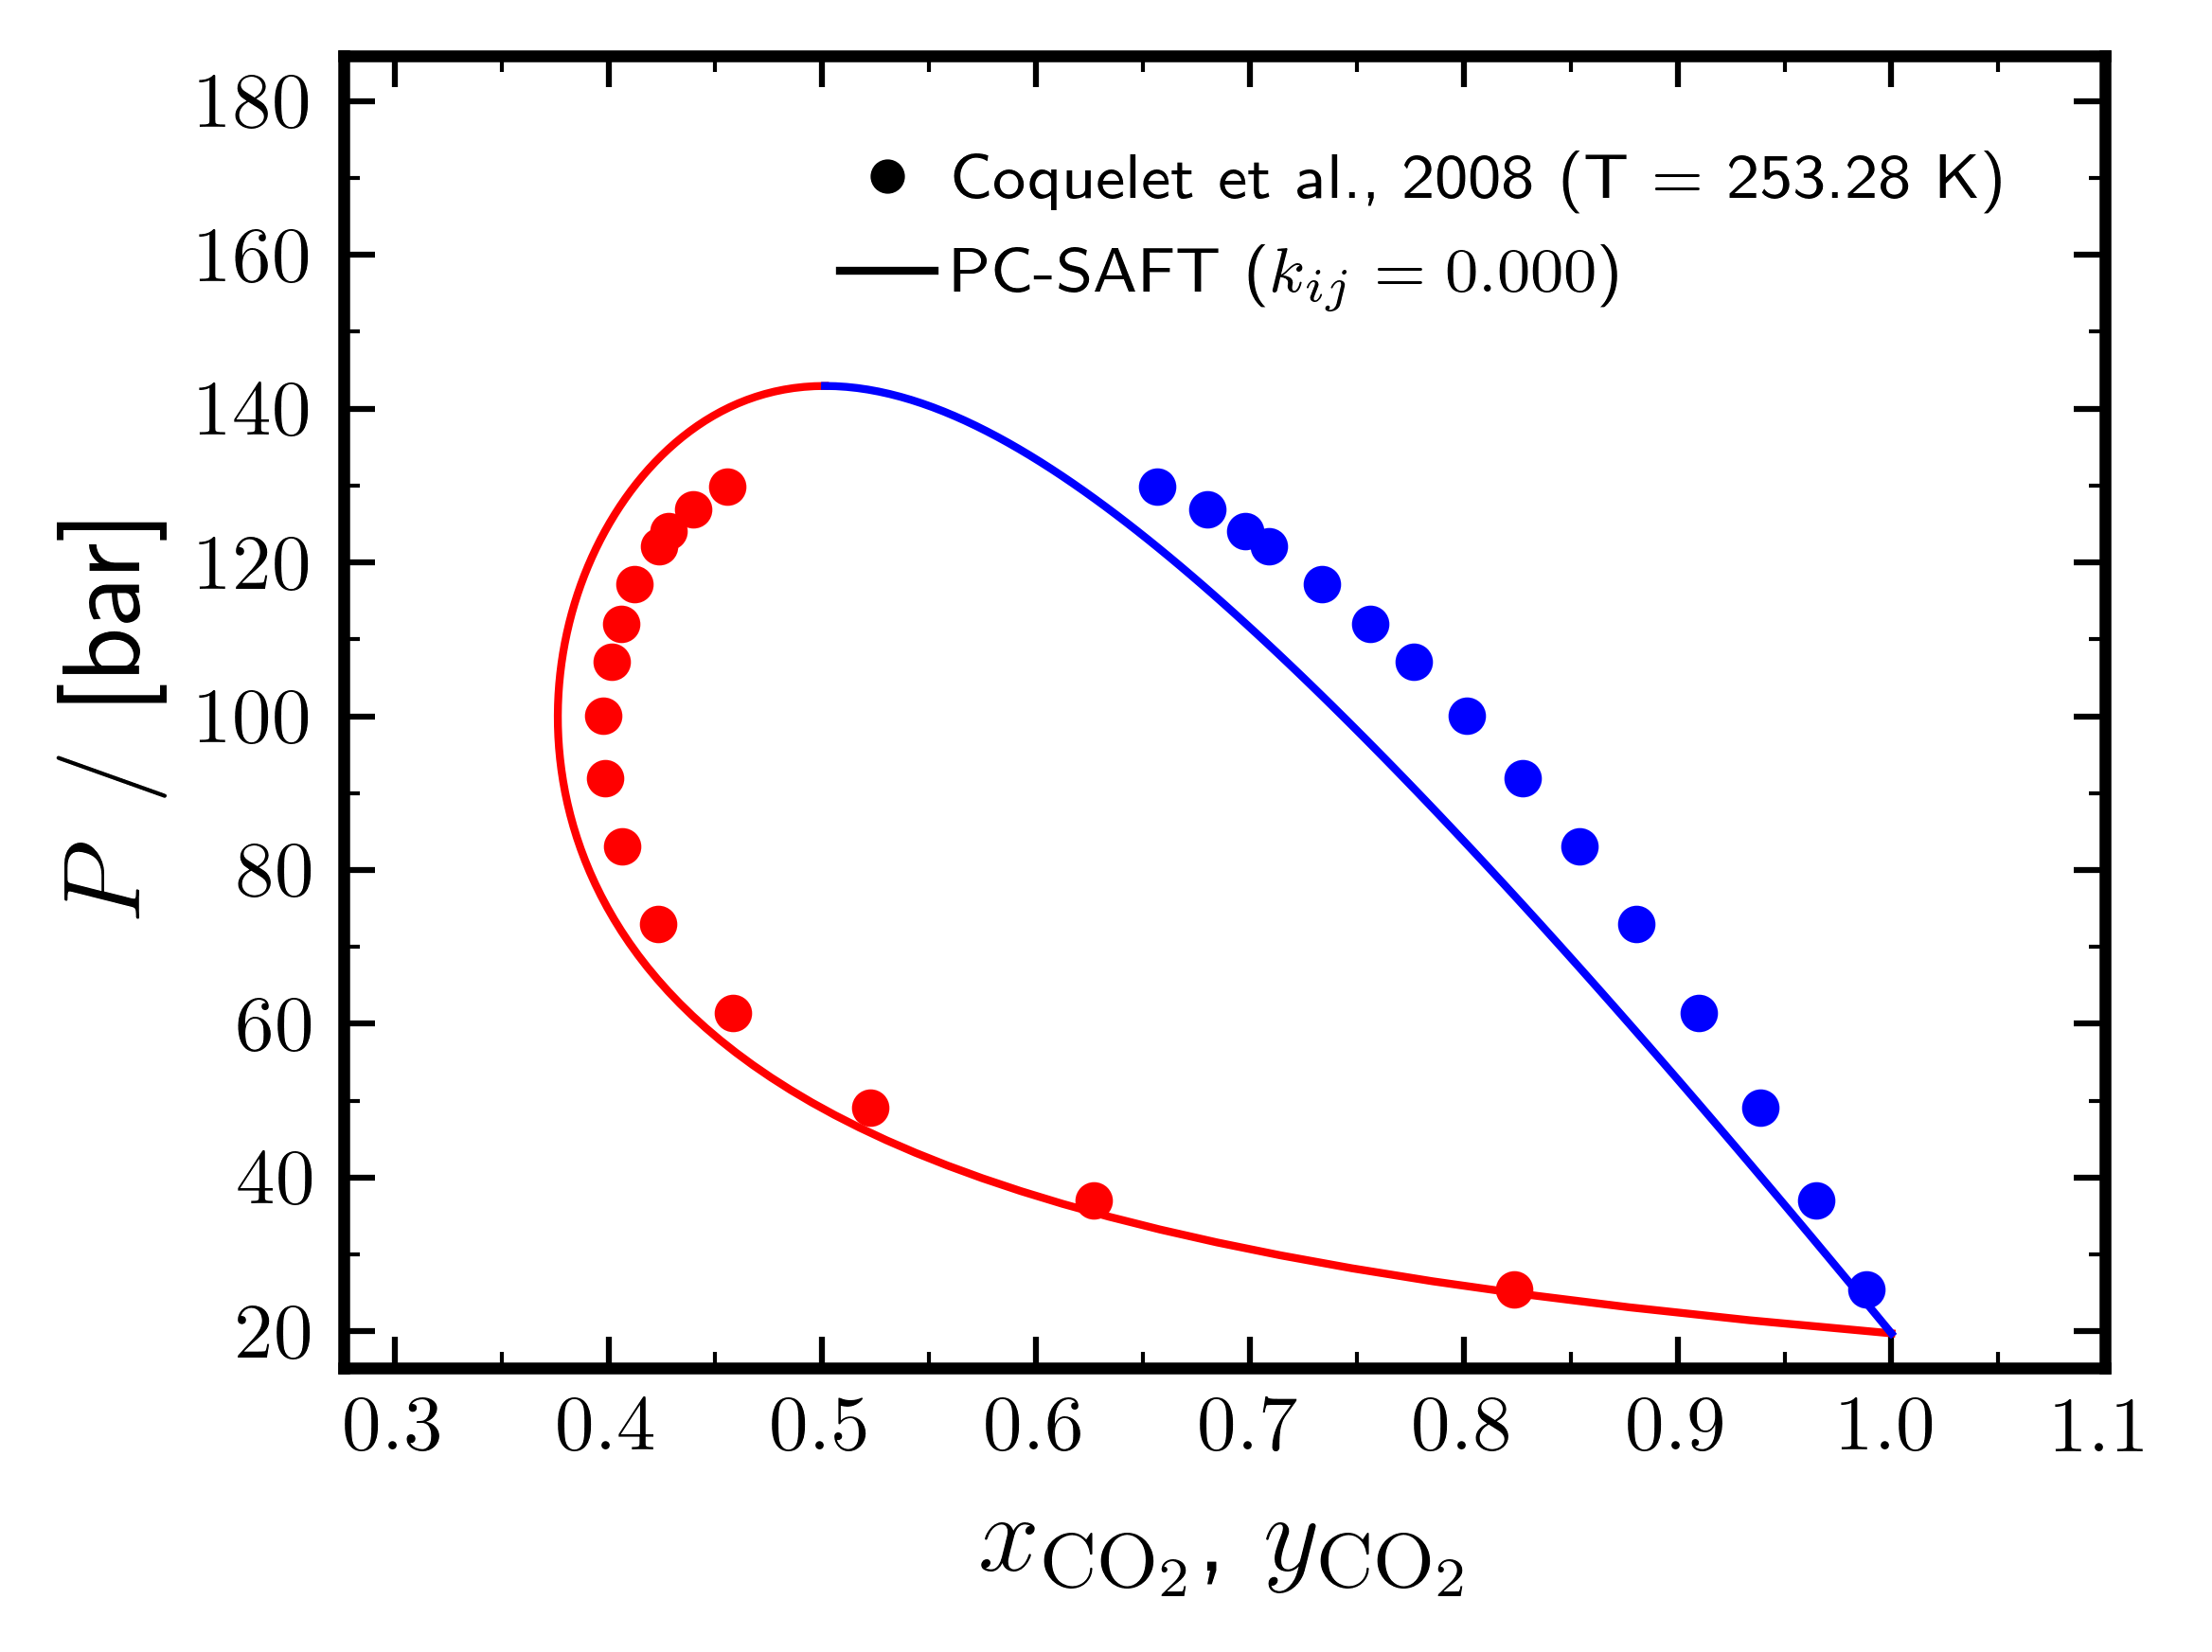

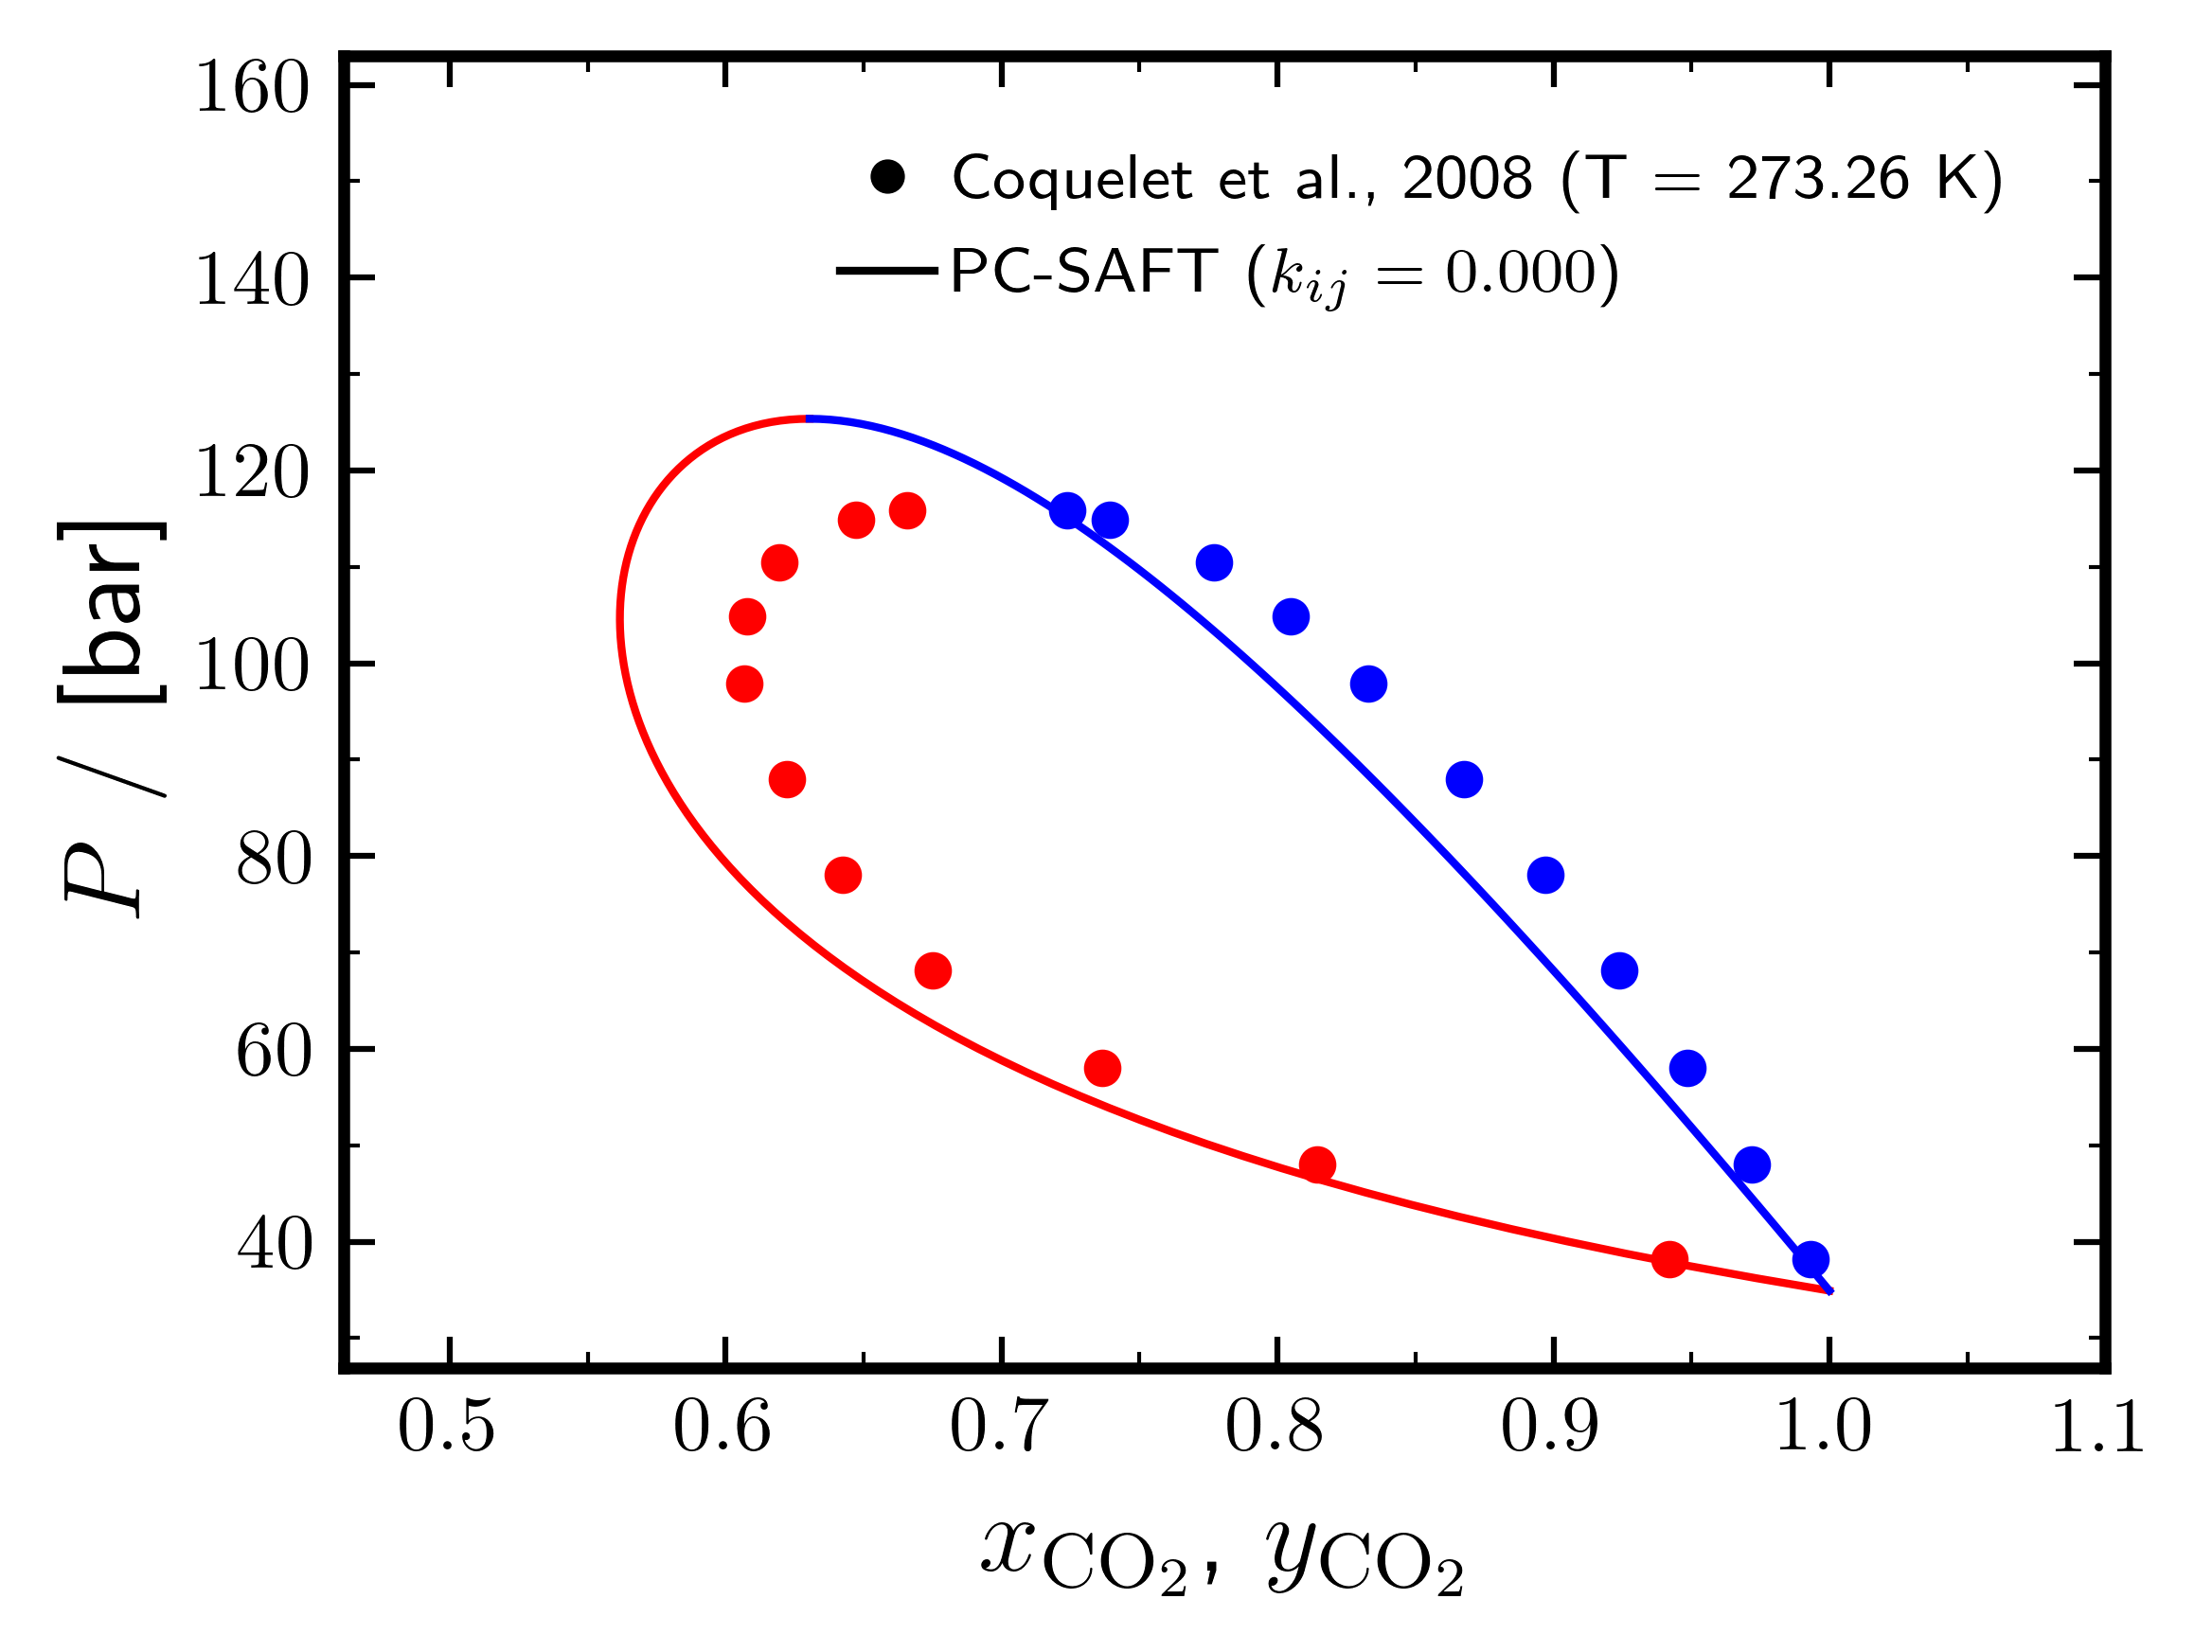

In [6]:
for T in data[cols["T"]].unique():
    VLE_PLOT(data, cols, T, 0)
    plt.show()

In [7]:
kij_distance = []

for T in data[cols["T"]].unique():

    isotherm = data[data[cols["T"]] == T]

    if 'fitted_kij' not in locals() or fitted_kij is None:
        initial_kij = [0.0]
    else:
        initial_kij = [fitted_kij[0]]
    
    isotherms = [
        DataSet.binary_phase_diagram(T*KELVIN, isotherm[cols["P"]].values * BAR, isotherm[cols["x1"]].values,
            isotherm[cols["y1"]].values,npoints=100)]

    estimator = Estimator(isotherms, weights=[1], losses=[Loss.linear()])
    
    fitted_kij = least_squares(cost, initial_kij, bounds=[-0.5, 0.5], args=(estimator,), verbose=2).x
    
    kij_distance.append(fitted_kij[0])

    mard_distance = estimator.mean_absolute_relative_difference(eos_from_kij(fitted_kij)) * 100

    kij_file = os.path.join("PLOTS", "kij_all.csv")

    write_header = not os.path.exists(kij_file)
    with open(kij_file, "a", newline="") as f:
        writer = csv.writer(f)
        if write_header:
            writer.writerow(["Optimization type", "Temperature_[K]", "kij", "MARD_percentage"])
        writer.writerow(["distance", T, fitted_kij[0], mard_distance.mean()])

    print(f"\033[1mOptimized kij value at T = {T} K: {fitted_kij[0]:.6f}\033[0m")
    
    print(f"MARD (distance,   k_ij = {fitted_kij[0]:>6.4}) = {mard_distance.mean():>8.4} %")

/tmp/ipykernel_3056411/2373019003.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  p = PcSaftParameters.new_binary(parameters.pure_records, kij)


   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.5696e-05                                    3.17e-04    
       1              2         4.9500e-06      1.07e-05       3.01e-02       1.70e-05    
       2              3         4.9200e-06      3.01e-08       1.59e-03       3.07e-07    
       3              4         4.9199e-06      6.10e-12       2.53e-05       4.43e-08    
       4              5         4.9199e-06      1.64e-13       4.16e-06       8.27e-09    
`gtol` termination condition is satisfied.
Function evaluations 5, initial cost 1.5696e-05, final cost 4.9199e-06, first-order optimality 8.27e-09.
Optimized kij value at T = 223.07 K: 0.031677
MARD (distance,   k_ij = 0.03168) =    1.602 %
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.9407e-06                                    8.08e-06    
       1              2        

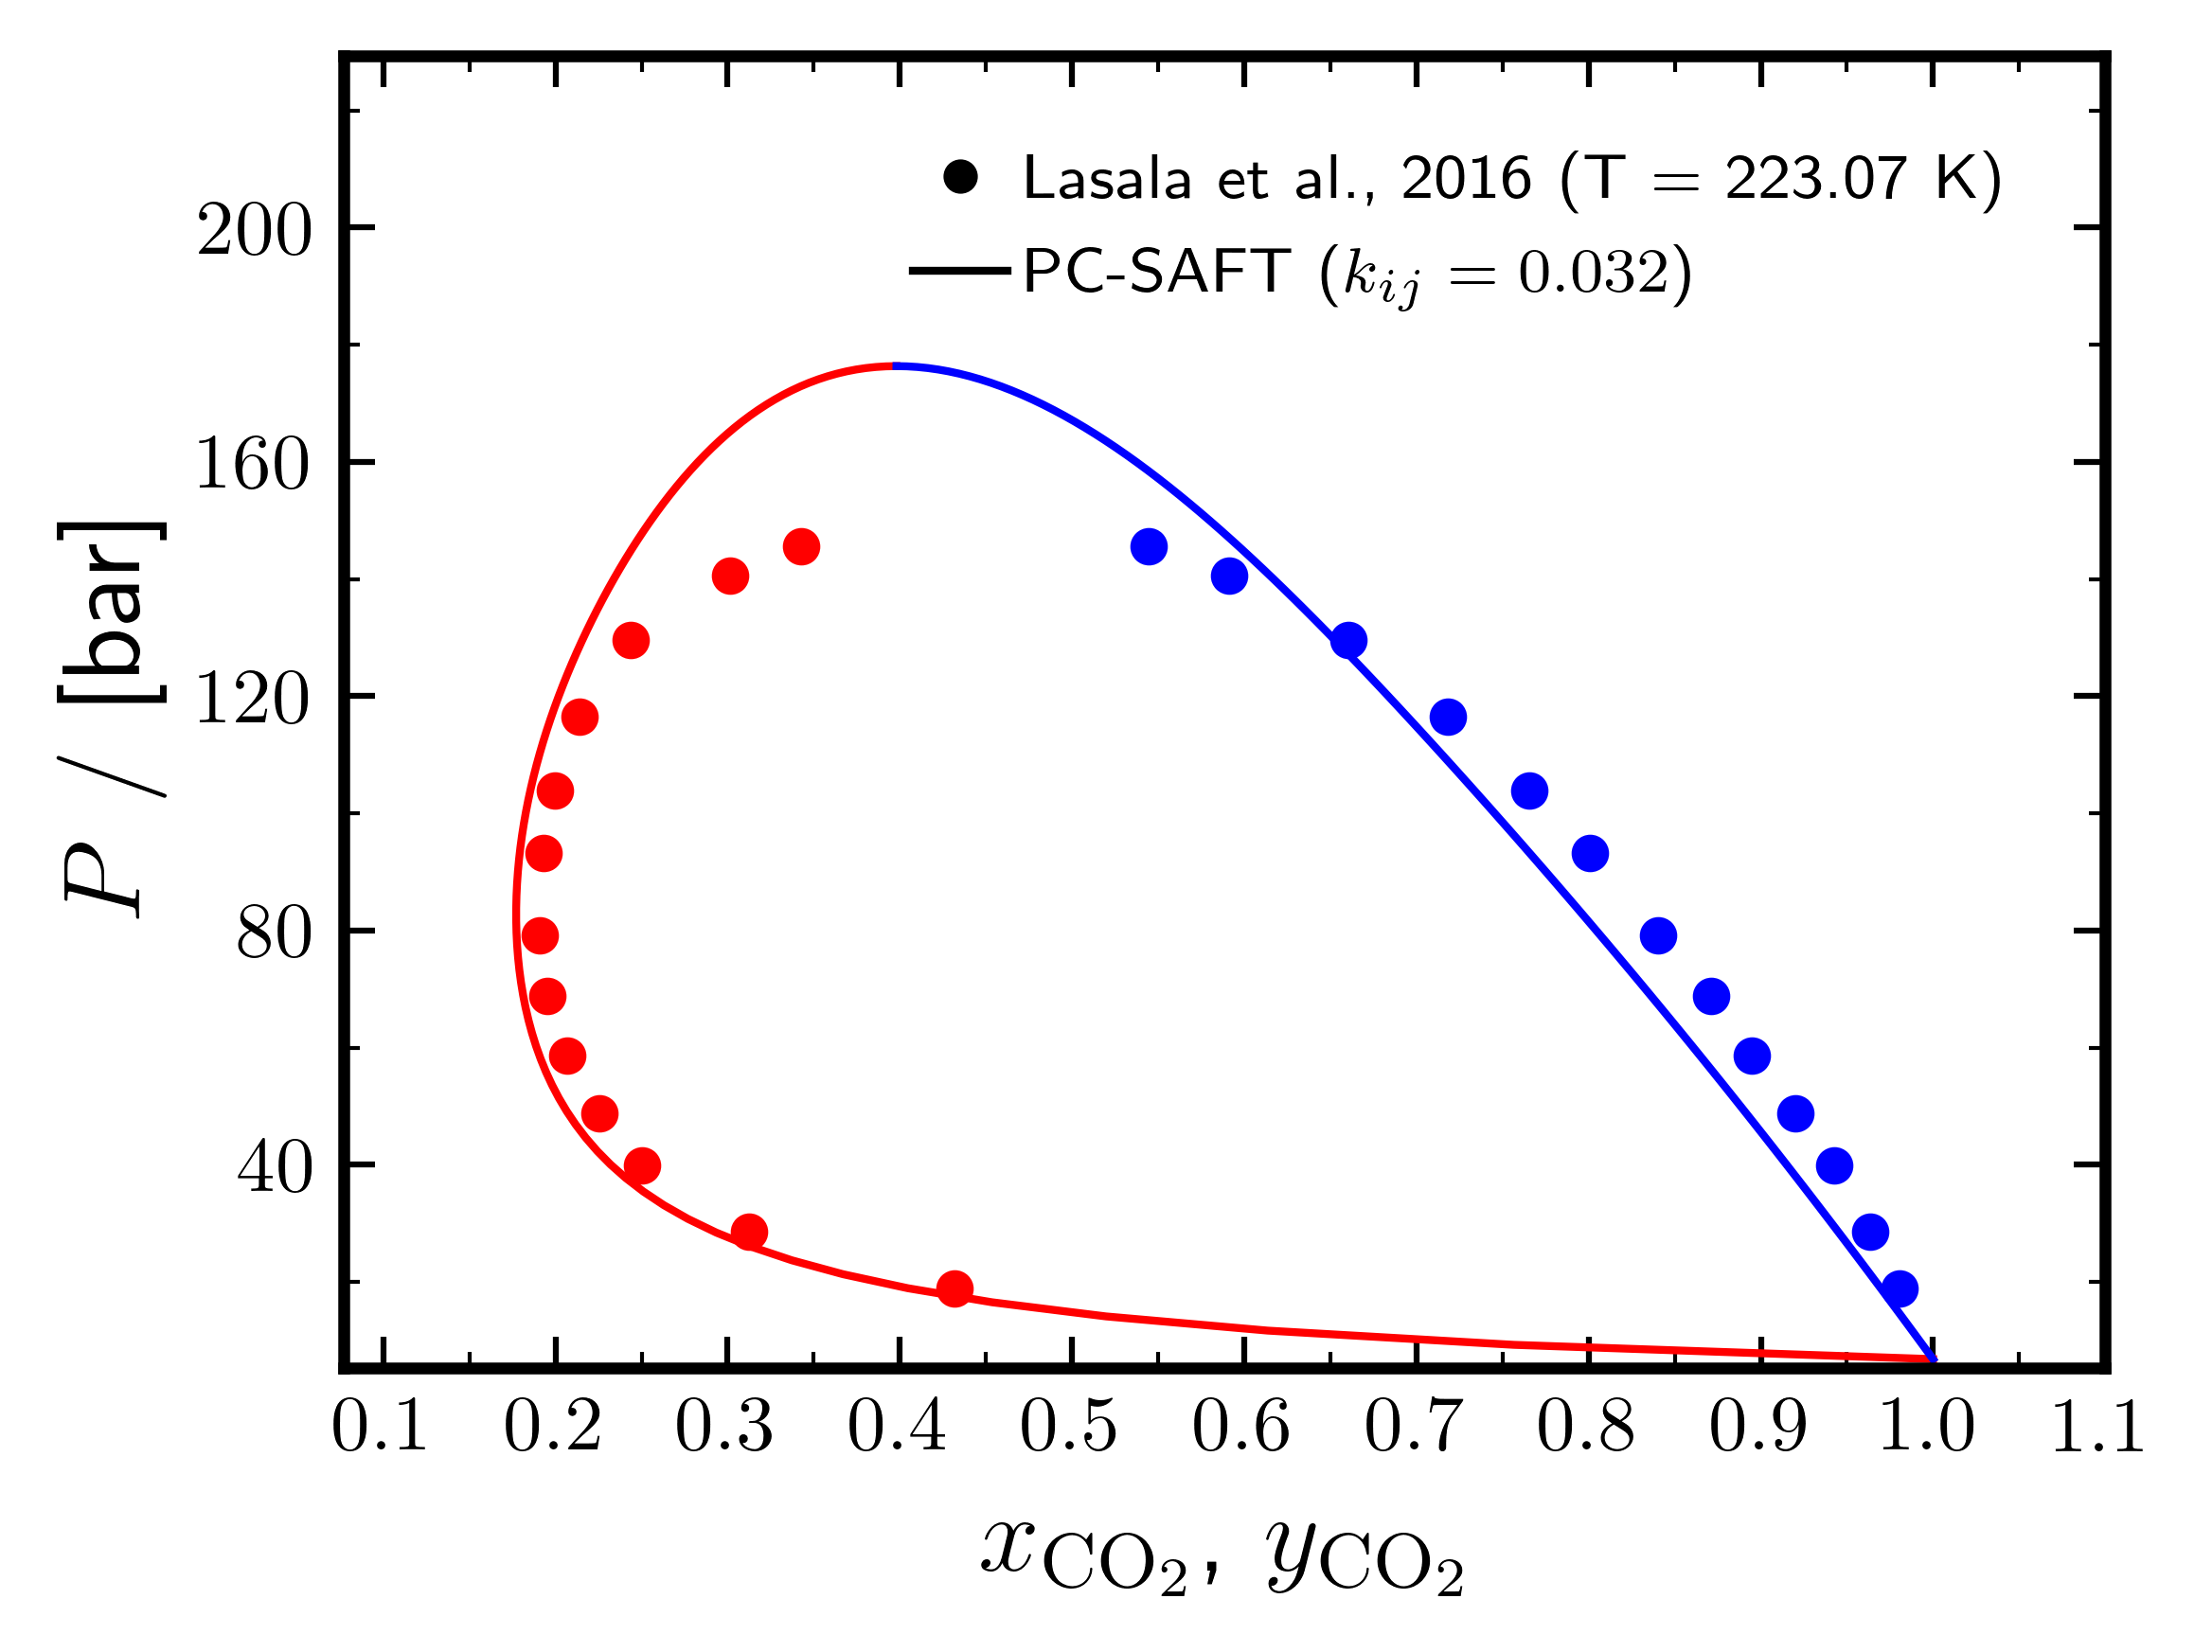

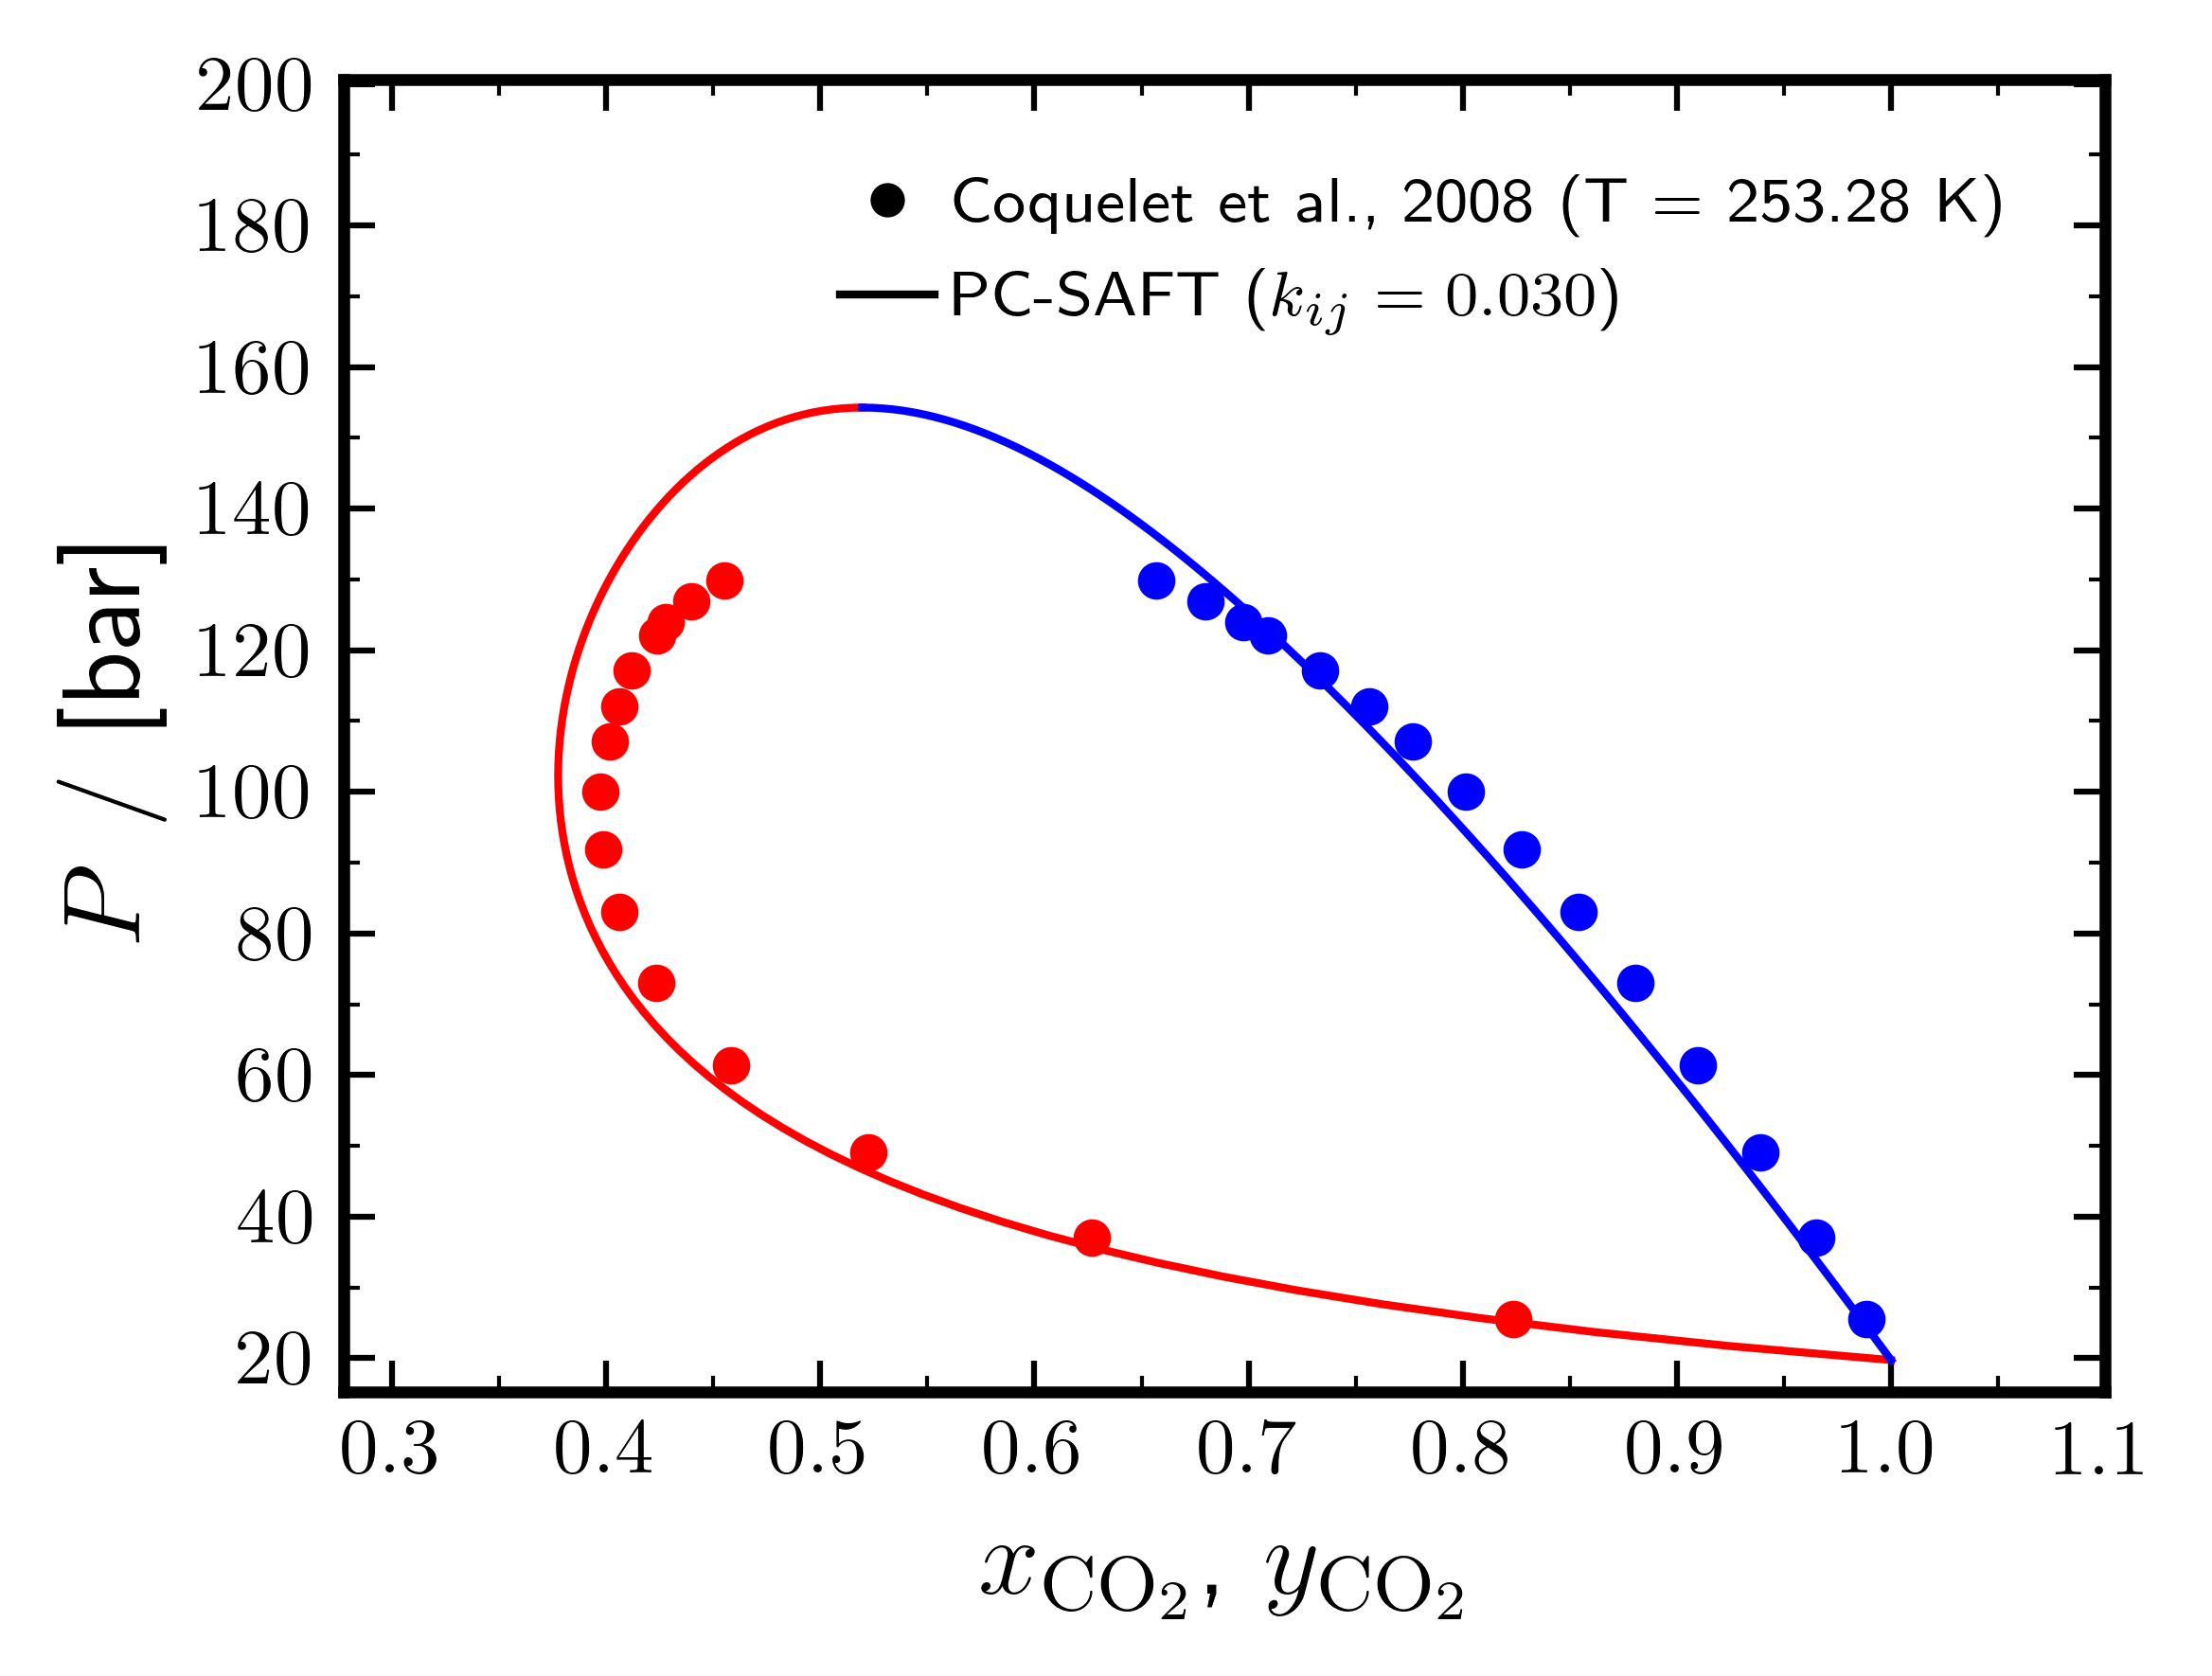

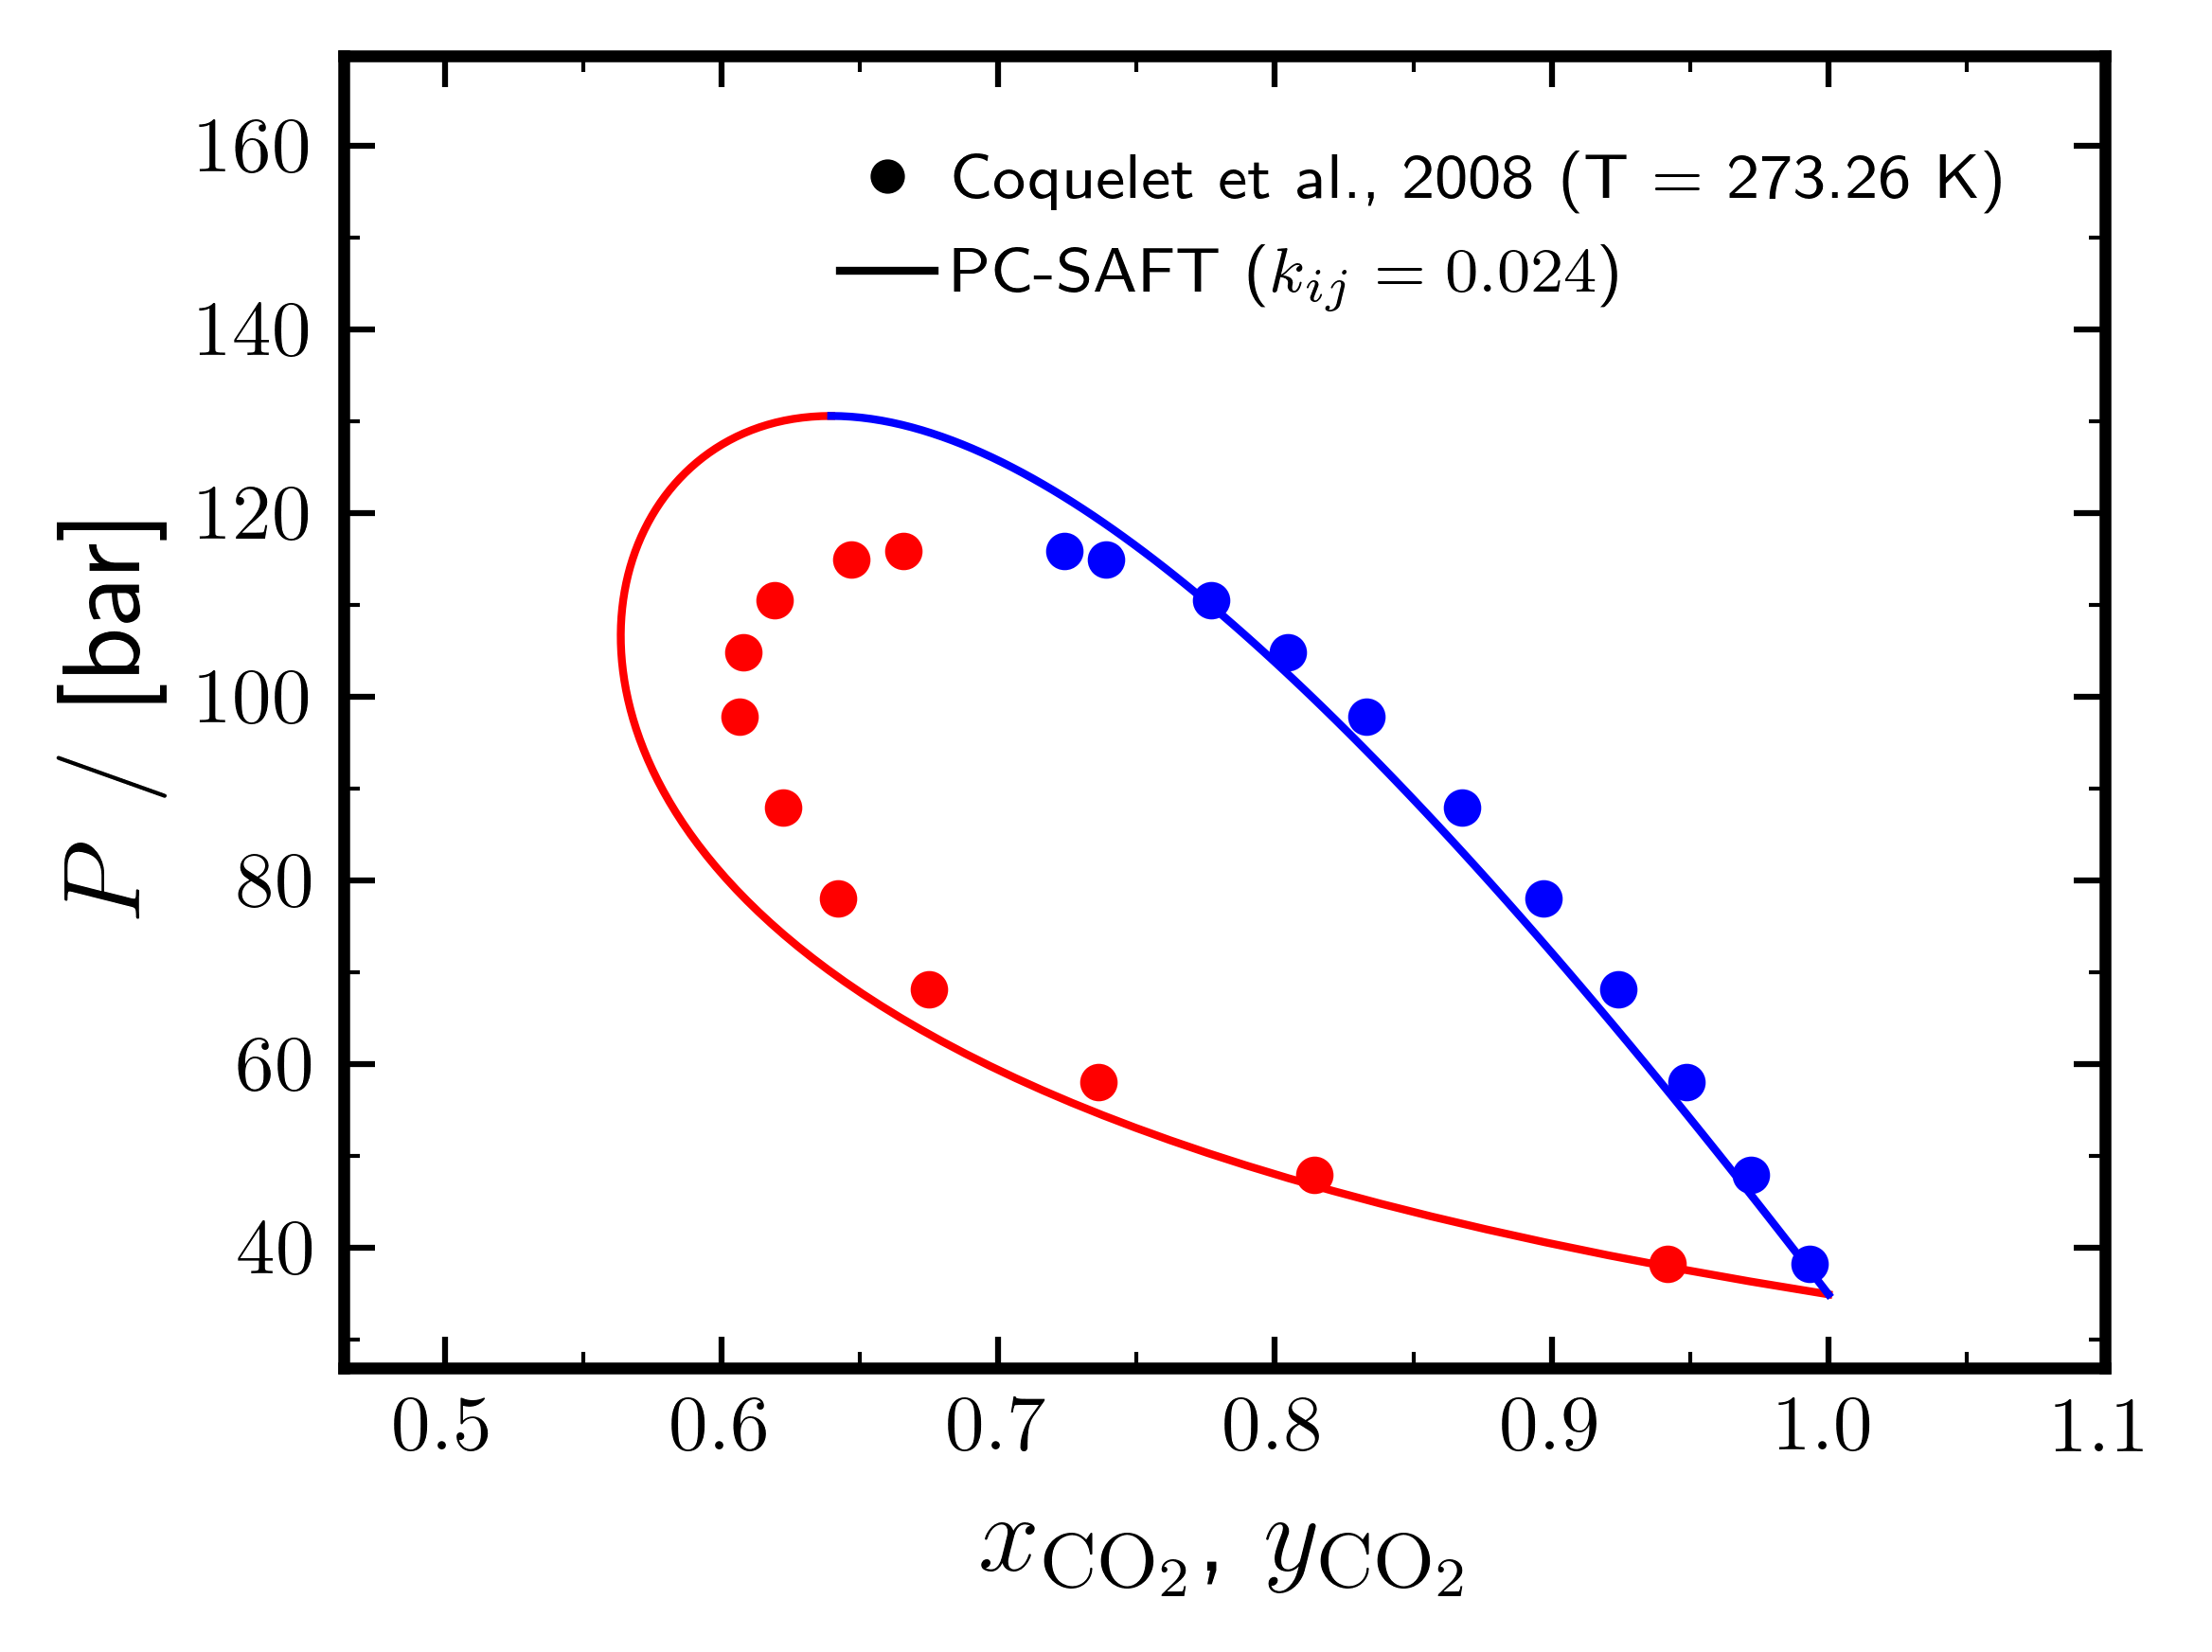

In [8]:
for T, kij in zip(data[cols["T"]].unique(), kij_distance):
    VLE_PLOT(data, cols, T, kij)
    plt.show()

In [9]:
kij_mu = []

for T in data[cols["T"]].unique():

    isotherm = data[data[cols["T"]] == T]

    if 'fitted_kij' not in locals() or fitted_kij is None:
        initial_kij = [0.0]
    else:
        initial_kij = [fitted_kij[0]]
        
    isotherms = [
        DataSet.binary_vle_chemical_potential(np.array([T]*len(isotherm)) *KELVIN, 
            isotherm[cols["P"]].values * BAR, isotherm[cols["x1"]].values,
            isotherm[cols["y1"]].values,)]
    
    estimator_mu = Estimator(isotherms, weights=[1]*3, losses=[Loss.linear()]*3)

    fitted_kij_mu = least_squares(cost, initial_kij, bounds=[-0.5, 0.5], args=(estimator_mu,), verbose=2).x

    kij_mu.append(fitted_kij_mu[0])

    mard_mu = estimator_mu.mean_absolute_relative_difference(eos_from_kij(fitted_kij_mu)) * 100

    kij_file = os.path.join("PLOTS", "kij_all.csv")

    write_header = not os.path.exists(kij_file)
    with open(kij_file, "a", newline="") as f:
        writer = csv.writer(f)
        if write_header:
            writer.writerow(["Optimization type", "Temperature_[K]", "kij", "MARD_percentage"])
        writer.writerow(["chemical potential", T, fitted_kij_mu[0], mard_mu.mean()])

    print(f"\033[1mOptimized kij value at T = {T} K: {fitted_kij_mu[0]:.6f}\033[0m")
    print(f"MARD (chem. pot., k_ij = {fitted_kij_mu[0]:>6.4}) = {mard_mu.mean():>8.4} %")

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.1236e-05                                    2.35e-04    
       1              2         3.5707e-06      7.67e-06       2.40e-02       6.68e-05    
       2              3         2.7904e-06      7.80e-07       1.02e-02       2.66e-06    
       3              4         2.7891e-06      1.32e-09       4.30e-04       4.50e-08    
       4              5         2.7891e-06      3.77e-13       7.28e-06       7.15e-10    
`gtol` termination condition is satisfied.
Function evaluations 5, initial cost 1.1236e-05, final cost 2.7891e-06, first-order optimality 7.15e-10.
Optimized kij value at T = 223.07 K: 0.058634
MARD (chem. pot., k_ij = 0.05863) =     3.33 %
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         2.0692e-06                                    6.69e-05    
       1              2        

/tmp/ipykernel_3056411/2373019003.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  p = PcSaftParameters.new_binary(parameters.pure_records, kij)


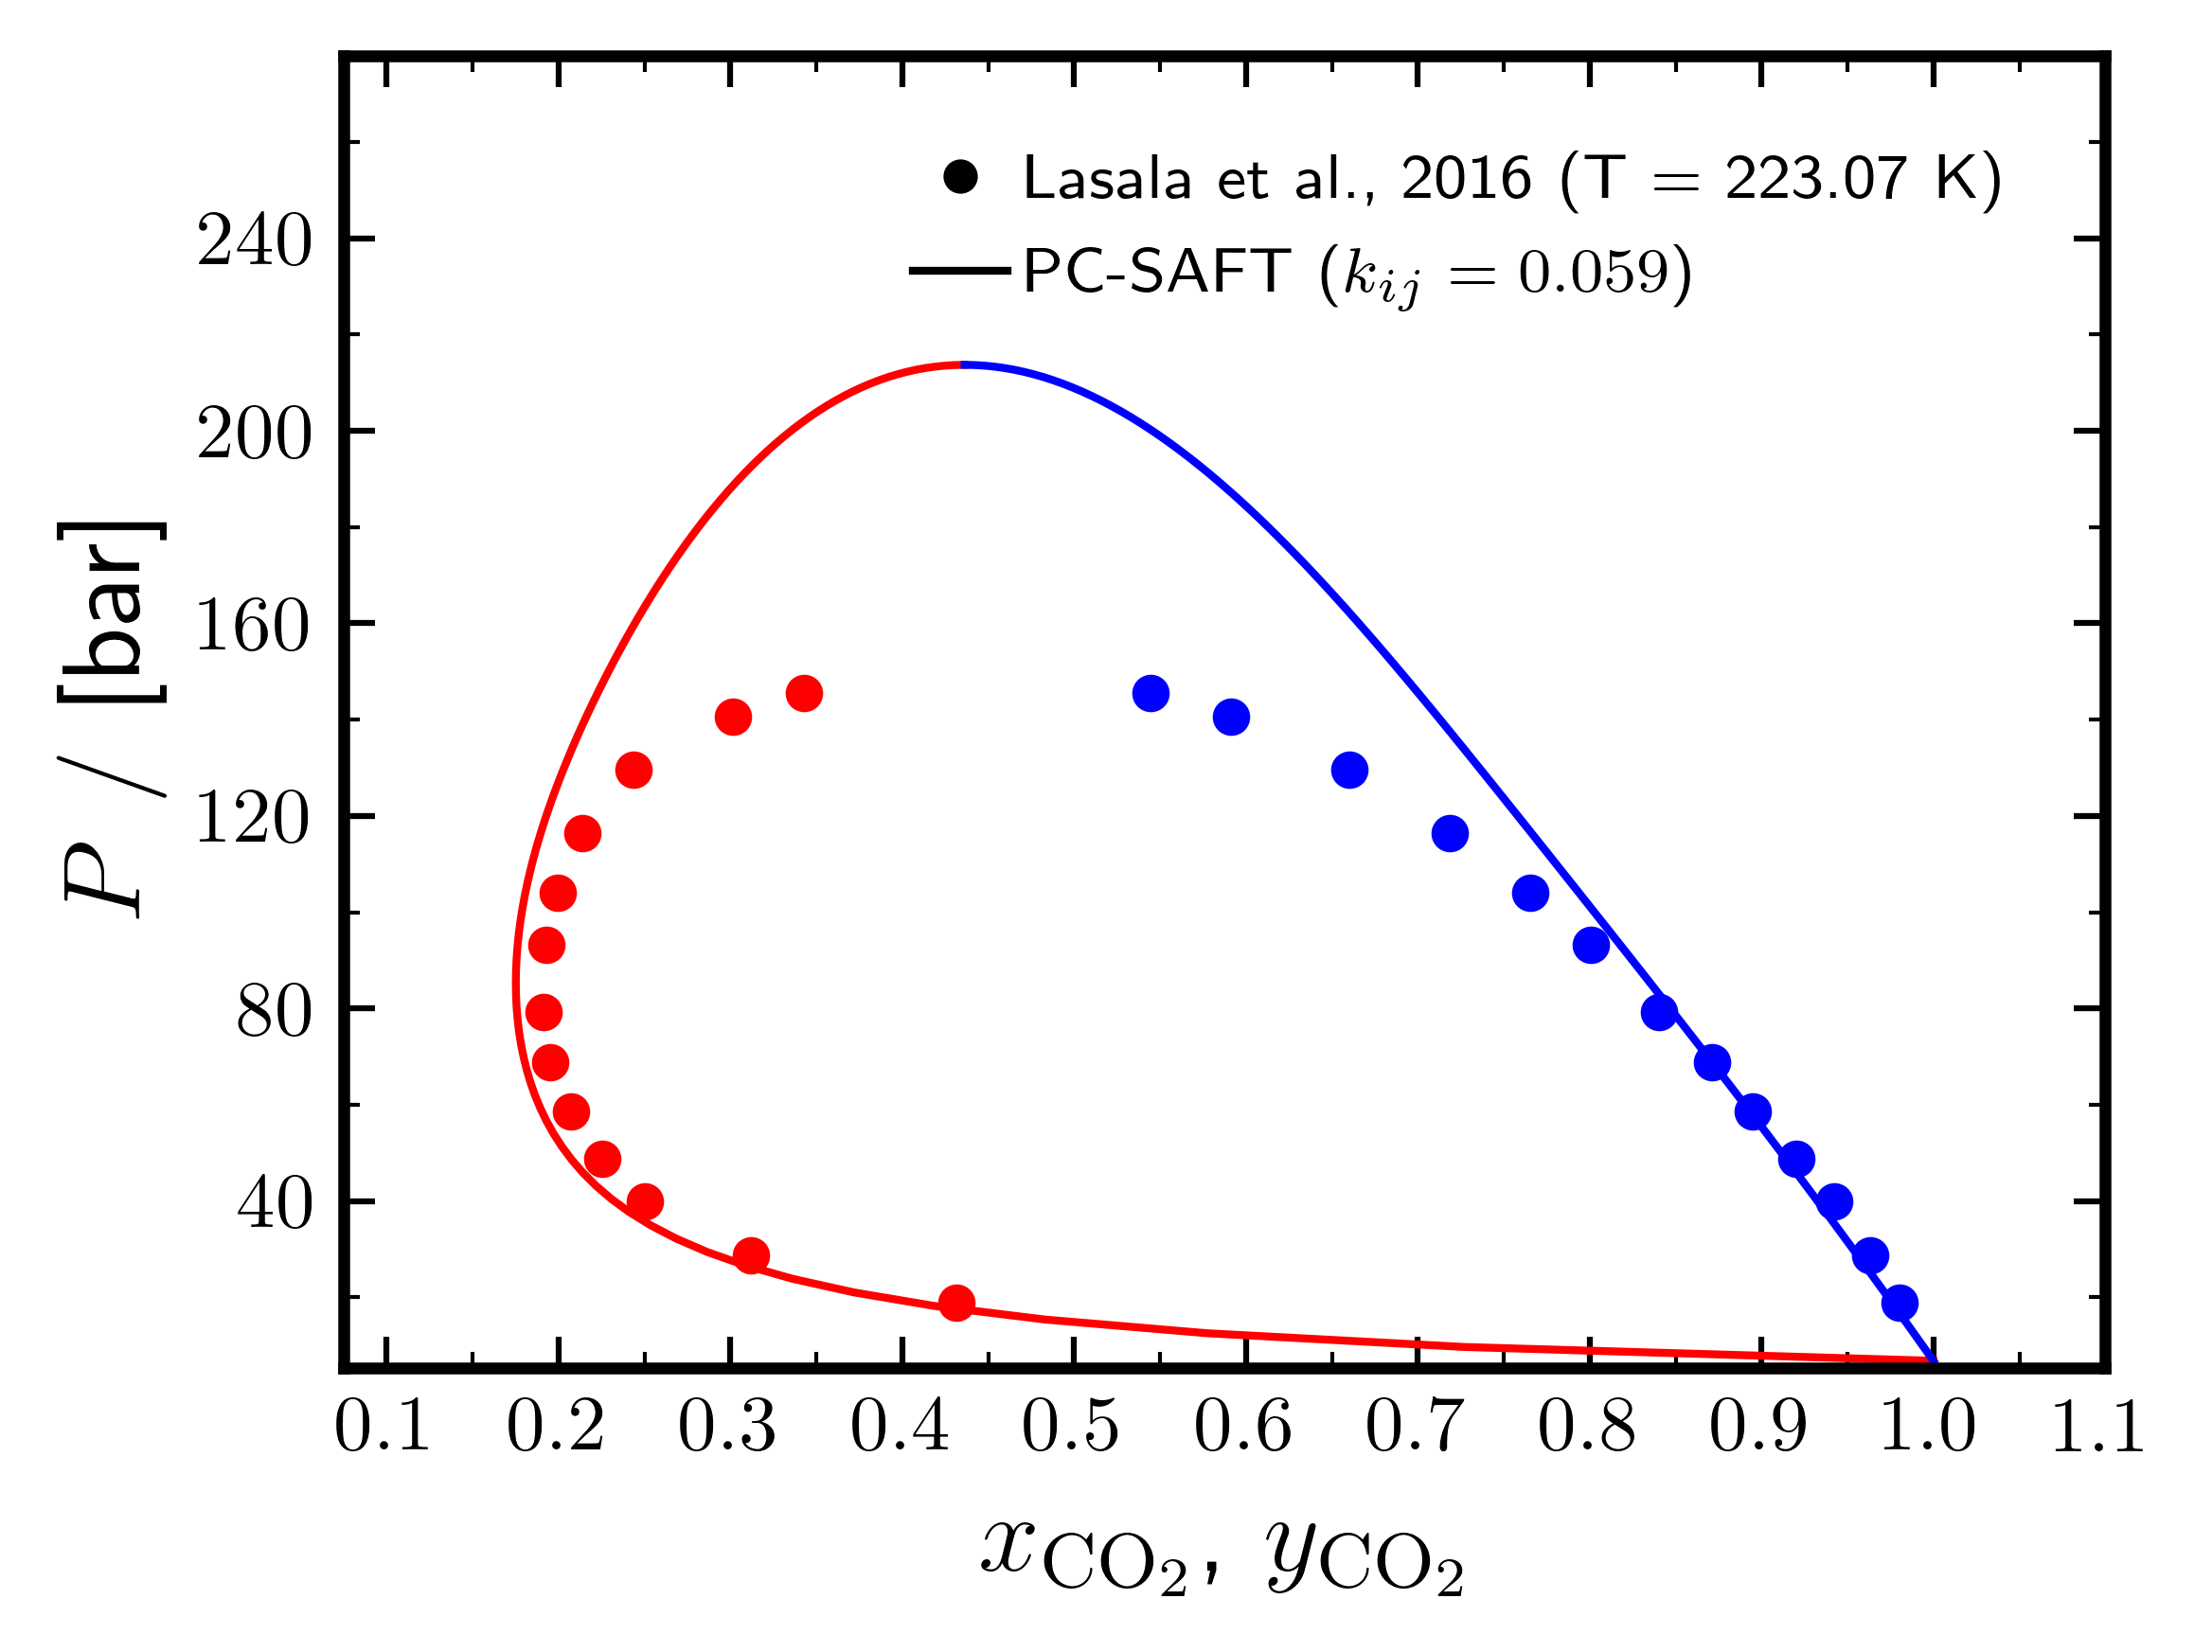

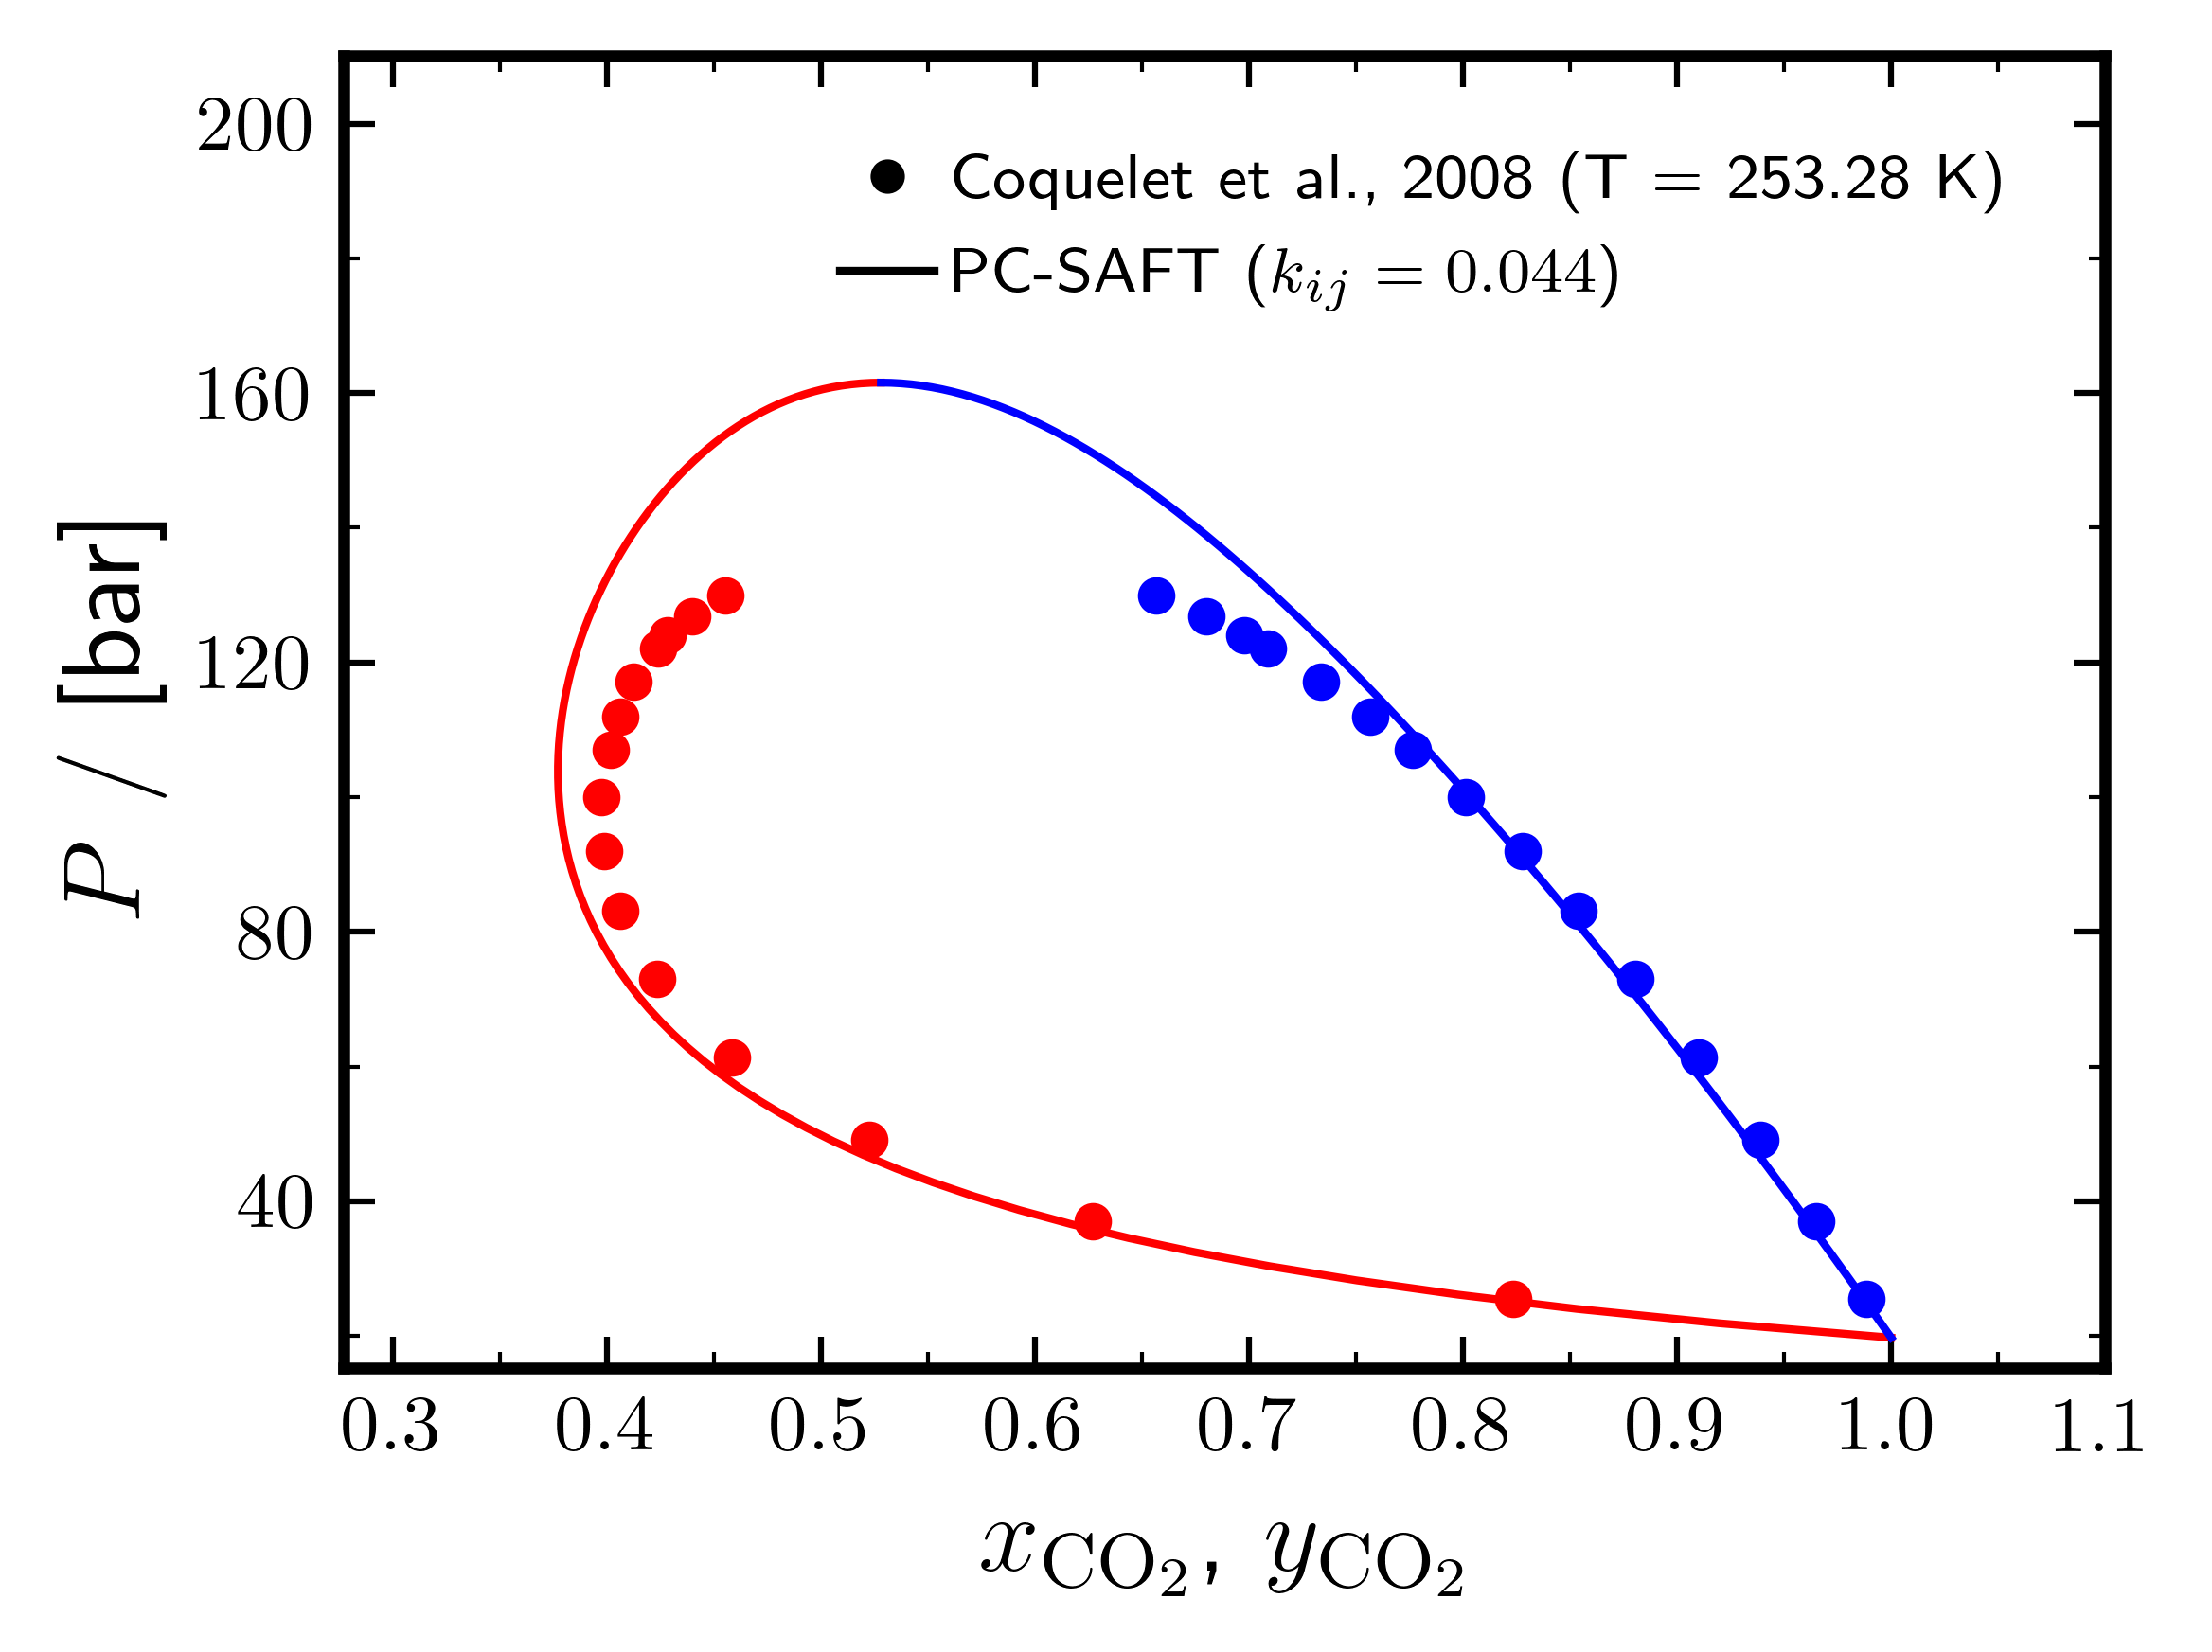

In [ ]:
for T, kij in zip(data[cols["T"]].unique(), kij_mu):
    VLE_PLOT(data, cols, T, kij)
    plt.show()

In [ ]:
kij_pressure = []

for T in data[cols["T"]].unique():

    isotherm = data[data[cols["T"]] == T]

    if 'fitted_kij' not in locals() or fitted_kij is None:
        initial_kij = [0.0]
    else:
        initial_kij = [fitted_kij[0]]

    isotherms = [[DataSet.binary_vle_pressure(np.array([T]*len(isotherm))*KELVIN, 
                isotherm[cols["P"]].values * BAR, isotherm[cols["x1"]].values,Phase.Liquid)]]
    
    estimator_p = Estimator(list(chain.from_iterable(isotherms)), weights=[1]*6, losses=[Loss.linear()]*6)
    
    fitted_kij_p = least_squares(cost, initial_kij, bounds=[-1,1], args=(estimator_p,), verbose=2).x
    
    kij_pressure.append(fitted_kij_p[0])

    mard_p = estimator_p.mean_absolute_relative_difference(eos_from_kij(fitted_kij_p)) * 100
    
    kij_file = os.path.join("PLOTS", "kij_all.csv")

    write_header = not os.path.exists(kij_file)
    with open(kij_file, "a", newline="") as f:
        writer = csv.writer(f)
        if write_header:
            writer.writerow(["Optimization type", "Temperature_[K]", "kij", "MARD_percentage"])
        writer.writerow(["pressure", T, fitted_kij_p[0], mard_p.mean()])

    print(f"\033[1mOptimized kij value at T = {T} K: {fitted_kij_p[0]:.6f}\033[0m")
    print(f"MARD (pressure,   k_ij = {fitted_kij_p[0]:>6.4}) = {mard_p.mean():>8.4} %")

In [ ]:
for T, kij in zip(data[cols["T"]].unique(), kij_pressure):
    VLE_PLOT(data, cols, T, kij)
    plt.show()

In [ ]:
## KIJ Interpolation/Extrapolation

T_vals      = np.linspace(210, 280, 200)
df_KIJ      = pd.read_csv("PLOTS/kij_all.csv")
idx         = df_KIJ.groupby("Temperature_[K]")["MARD_percentage"].idxmin()
df_best_kij = df_KIJ.loc[idx].reset_index(drop=True)

print(df_best_kij)

In [ ]:
# Fit a 3rd order polynomial (cubic)
coeffs = np.polyfit(df_best_kij["Temperature_[K]"], df_best_kij["kij"], deg=3)
a, b, c, d = coeffs[3], coeffs[2], coeffs[1], coeffs[0]

print(f"\nFitted function:")
print(f"k_ij(T) = {a:.6f} + ({b:.6e})*T + ({c:.6e})*T² + ({d:.6e})*T³")

def kij_func(T):
    """Cubic correlation for k_ij(T)"""
    return a + b * T + c * T**2 + d * T**3

kij_vals = kij_func(T_vals)

In [ ]:
fig, ax = ps.plot_init()

ax.plot(df_best_kij["Temperature_[K]"], df_best_kij["kij"],linestyle="",
    linewidth=ps.linewidth,marker=ps.markers[0],markersize=ps.markersize,
    markeredgewidth=ps.markeredgewidth,color=ps.colors[0],
    label=r"$k_{ij}$ from epxerimental data")

ax.plot(T_vals,kij_vals,color='k',linewidth=ps.linewidth,
    label = r"3$^{\mathrm{rd}}$-order polynomial fit")

ax.set_xlabel(r"$T\,/\, \mathrm{[K]}$", fontsize=ps.label_fontsize)
ax.set_ylabel(r"$k_{ij}\, / \, [-]$", fontsize=ps.label_fontsize)

ps.style_legend(ax,loc='upper left',ncol=1,borderaxespad=1.0,frame=False)

ax.minorticks_on()
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.002))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.001))
ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(5))

ps.save_plot(fig, f"kij_{mixture.replace('-','-')}_vs_T")
plt.show()

In [ ]:
notebook_end = time.perf_counter()
print(f"Total notebook runtime: {notebook_end - notebook_start:.2f} s")